####  B Vidakovic Quantum Framework for Wavelet Shrinkage 
## Example 7

# Encoding Classical Data into Quantum Expectation Values and Kraus Phase-Damping

### Data Encoding into ⟨X⟩

We start with a classical sequence

$$
y = [2, 1, 9, 3, -10, 2, 4].
$$

To map arbitrary real values into a quantum expectation value, we rescale $y$ into the interval $[-1,1]$:

$$
x_i = 2 \cdot \frac{y_i - \min(y)}{\max(y) - \min(y)} - 1.
$$

Thus each $x_i \in [-1,1]$ can serve as a valid expectation value of the Pauli-$X$ operator.

---

### State Preparation

We use **3 qubits** for robustness. Each qubit is initialized into the $|+\rangle$ state:

$$
|+\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}.
$$

For $|+\rangle$, the expectation value of $X$ is

$$
\langle + | X | + \rangle = 1.
$$

---

### Encoding by $R_z(\phi)$ Rotation

We then apply a **$Z$-axis rotation** by angle $\phi$:

$$
R_z(\phi) = \exp\left(-i \frac{\phi}{2} Z\right).
$$

Acting on $|+\rangle$, the new state becomes

$$
|\psi(\phi)\rangle = R_z(\phi)|+\rangle.
$$

The expectation value of $X$ in this state is

$$
\langle \psi(\phi) | X | \psi(\phi) \rangle = \cos(\phi).
$$

Thus, by choosing

$$
\phi_i = \arccos(x_i),
$$

we directly encode each rescaled data point $x_i$ into the measurable quantum expectation value of $X$.

This is **not amplitude encoding** (which distributes data across amplitudes of computational basis states). Instead, it is **rotation-based encoding into operator expectation values**.

---

### Kraus Phase-Damping Noise Model

The **phase-damping channel** models the loss of quantum coherence without energy loss (pure dephasing).  
It acts on a single qubit density matrix $\rho$ as:

$$
\mathcal{E}(\rho) = K_0 \rho K_0^\dagger + K_1 \rho K_1^\dagger,
$$

where the **Kraus operators** are

$$
K_0 = \begin{bmatrix}
1 & 0 \\
0 & \sqrt{1 - \gamma}
\end{bmatrix}, \qquad
K_1 = \begin{bmatrix}
0 & 0 \\
0 & \sqrt{\gamma}
\end{bmatrix}.
$$

Here $\gamma \in [0,1]$ is the **decoherence strength**.

---

### Effect on Expectation Values

For a general qubit Bloch vector $(x,y,z)$, phase damping transforms it as:

$$
(x,y,z) \mapsto \big((1-\gamma)x,\,(1-\gamma)y,\,z\big).
$$

That is:
- The **off-diagonal elements** of $\rho$ (coherences) are suppressed by a factor $\sqrt{1-\gamma}$.
- The **diagonal elements** (populations) remain unchanged.

---

### In Our Encoding

Since we encoded $x_i$ into $\langle X \rangle = \cos(\phi_i)$, under phase damping we get

$$
\langle X \rangle_{\text{after}} = (1 - \gamma) \cdot \langle X \rangle_{\text{before}}.
$$

Thus, the quantum channel **shrinks** the sequence by a multiplicative factor $\sqrt{1 - \gamma}$.

For $\gamma = 0.5$, the measured values are ideally

$$
x_i^{\text{shrunk}} = \sqrt{0.5} \, x_i.
$$

### Note. Phase damping in Qiskit shrinks coherences by $\sqrt{1-\gamma}$, not $1-\gamma$.
---

## 3. Measurement Procedure

To measure $\langle X \rangle$:
1. Apply a **Hadamard gate** before measurement (to rotate the $X$ basis into the computational $Z$ basis).
2. Measure in the $Z$ basis.
3. Compute

$$
\langle X \rangle = 2 \cdot P(0) - 1,
$$

where $P(0)$ is the probability of outcome "0".

Averaging across 3 qubits yields the final estimate of each data point after damping.

---


## Comparing Phase Damping vs. Pauli-$Z$ Flip Channels

Both channels reduce coherence, but the way they act on the off-diagonal terms is **different**.

---

### 1. Phase Damping Channel

Kraus operators:

$$
K_0 = \begin{bmatrix} 1 & 0 \\ 0 & \sqrt{1-\gamma} \end{bmatrix}, \qquad
K_1 = \begin{bmatrix} 0 & 0 \\ 0 & \sqrt{\gamma} \end{bmatrix}.
$$

Action on density matrix:

$$
\mathcal{E}_{\text{phase}}(\rho) =
\begin{bmatrix}
\rho_{00} & \sqrt{1-\gamma}\,\rho_{01} \\
\sqrt{1-\gamma}\,\rho_{10} & \rho_{11}
\end{bmatrix}.
$$

- Diagonal terms unchanged.  
- Off-diagonal terms shrink by **$\sqrt{1-\gamma}$**.  

Therefore:

$$
\langle X \rangle_{\text{after}} = \sqrt{1-\gamma}\,\langle X \rangle_{\text{before}}.
$$

---

### 2. Pauli-$Z$ Flip Channel

Kraus operators (probability $p$ of applying $Z$):

$$
K_0 = \sqrt{1-p}\, I, \qquad
K_1 = \sqrt{p}\, Z.
$$

Action on density matrix:

$$
\mathcal{E}_{Z\text{-flip}}(\rho) = (1-p)\rho + p\,Z\rho Z.
$$

For
$$
\rho = \begin{bmatrix}
\rho_{00} & \rho_{01} \\
\rho_{10} & \rho_{11}
\end{bmatrix},
$$
this gives
$$
\mathcal{E}_{Z\text{-flip}}(\rho) =
\begin{bmatrix}
\rho_{00} & (1-2p)\,\rho_{01} \\
(1-2p)\,\rho_{10} & \rho_{11}
\end{bmatrix}.
$$

- Diagonal terms unchanged.  
- Off-diagonal terms shrink by **$(1-2p)$**.  

Therefore:

$$
\langle X \rangle_{\text{after}} = (1-2p)\,\langle X \rangle_{\text{before}}.
$$

---

### Key Difference

- **Phase damping**: coherence factor = $\sqrt{1-\gamma}$.  
- **Pauli-$Z$ flip**: coherence factor = $(1-2p)$.  

Although both channels suppress superpositions, the *functional dependence* on the noise parameter differs:
- Phase damping comes from a **continuous-loss Kraus process**.  
- Pauli-$Z$ flip is a **discrete probabilistic error model**.

---


# Phase Damping with Data-Dependent Strength: $\gamma_i = f(x_i)$

## Context
Given a rescaled classical sequence $x_i \in [-1,1]$ (e.g., obtained from raw $y_i$ by min–max scaling), we encode each $x_i$ into the expectation value of the Pauli-$X$ operator on a qubit. Using the rotation-based encoding described earlier, we prepare a state whose $\langle X\rangle$ equals the target $x_i$.

## Phase Damping Channel (Kraus Form)
The single-qubit phase-damping (pure dephasing) channel with strength $\gamma \in [0,1]$ has Kraus operators
$$
K_0=\begin{bmatrix}1&0\\0&\sqrt{1-\gamma}\end{bmatrix},\quad
K_1=\begin{bmatrix}0&0\\0&\sqrt{\gamma}\end{bmatrix}.
$$
Acting on a density matrix $\rho$, off-diagonal terms are multiplied by $\sqrt{1-\gamma}$ while populations are unchanged. Consequently,
$$
\langle X\rangle \mapsto \sqrt{1-\gamma}\,\langle X\rangle,\qquad
\langle Y\rangle \mapsto \sqrt{1-\gamma}\,\langle Y\rangle,\qquad
\langle Z\rangle \mapsto \langle Z\rangle.
$$

## Making $\gamma$ Depend on the Data: $\gamma_i=f(x_i)$
You can choose a (classical) function $f:[-1,1]\to[0,1]$ and set a per-timestep damping strength $\gamma_i=f(x_i)$.

- **Single-shot (re-prepare each $x_i$):** If for each $i$ you freshly prepare the state with $\langle X\rangle=x_i$ and then apply the channel with $\gamma_i$, the ideal post-channel value is
  $$
  \langle X\rangle_{\text{after},i}=\sqrt{1-\gamma_i}\;x_i.
  $$
- **Cumulative evolution (no re-preparation):** If you start from $\langle X\rangle=x_0$ and apply channels with strengths $\gamma_1,\gamma_2,\dots,\gamma_T$ in sequence on the *same* state, then
  $$
  \langle X\rangle_T=\Bigg(\prod_{k=1}^{T}\sqrt{1-\gamma_k}\Bigg)\,x_0.
  $$

### Examples of $f(x)$
Ensure $0\le f(x)\le 1$ for all $x\in[-1,1]$.
- Linear magnitude: $\gamma_i = \alpha |x_i|$ (pick $\alpha\le 1$).
- Quadratic: $\gamma_i = \alpha x_i^2$ (pick $\alpha\le 1$).
- Complement of magnitude: $\gamma_i = 1-|x_i|$.
  
For the two choices used in the examples:
- If $\gamma_i=|x_i|$, then $\langle X\rangle_{\text{after},i}=\sqrt{1-|x_i|}\,x_i$.
- If $\gamma_i=1-|x_i|$, then $\langle X\rangle_{\text{after},i}=\sqrt{|x_i|}\,x_i$.

## Physical Interpretation (and a Caution)
- **Classical schedule (valid):** Choosing $\gamma_i=f(x_i)$ *externally* from classical data (time-dependent noise) is a standard, physically meaningful **time-inhomogeneous** noise model. Each step still applies a legitimate CPTP map; only the parameter changes over time.
- **State-dependent map (caution):** If $\gamma$ were to depend on the *quantum state itself* (not on external classical data), the overall map would generally be **nonlinear** in $\rho$ and thus **not** a standard CPTP quantum channel. Use such models only as effective or toy descriptions.

## Implementation Note (Qiskit 2.x)
Per timestep $i$, build and insert the Kraus instruction with the chosen $\gamma_i=f(x_i)$:
```python
from qiskit_aer.noise import phase_damping_error

gamma_i = f(x_i)  # must be in [0,1]
err_instr = phase_damping_error(gamma_i).to_instruction()
for q in range(n_qubits):
    qc.append(err_instr, [q])  # explicit insertion; survives transpilation


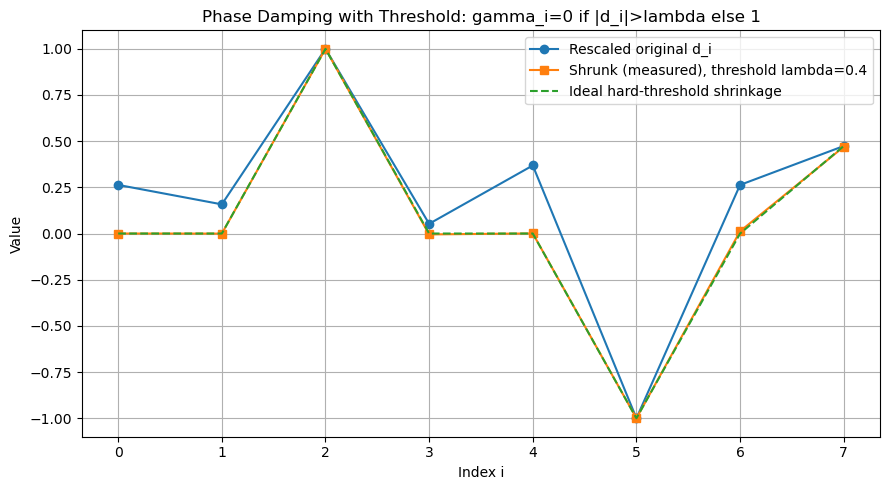

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit_aer.noise import phase_damping_error

# ----- Data -----
dd = np.array([2, 1, 9, 0, 3, -10, 2, 4], dtype=float)

# Rescale to [-1, 1] for encoding into <X>
d = 2 * (dd - dd.min()) / (dd.max() -dd.min()) - 1

# ----- Threshold parameter -----
lambda_ = 0.4  # choose in [0, 1]; adjust as you like

def gamma_threshold(val, lam):
    """gamma_i = 0 if |x_i|>lam, else 1"""
    return 0.0 if abs(val) > lam else 1.0

# ----- Quantum setup -----
n_qubits = 3
shots = 8192
backend = Aer.get_backend("aer_simulator")

def avg_d_expectation(counts, n_qubits=3):
    """Average <X> across qubits from counts measured after H (X-basis)."""
    total = sum(counts.values())
    avg = 0.0
    for i in range(n_qubits):
        p0 = sum(c for bitstr, c in counts.items() if bitstr[::-1][i] == '0') / total
        avg += (2 * p0 - 1)
    return avg / n_qubits

observed = []
theoretical = []

for val in d:
    gamma_i = gamma_threshold(val, lambda_)
    err_instr = phase_damping_error(gamma_i).to_instruction()

    # Circuit: encode x_i into <X> via Rz(phi), apply phase damping, measure in X-basis
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))  # |+>^⊗
    phi = float(np.arccos(np.clip(val, -1.0, 1.0)))  # cos(phi) = x_i
    qc.rz(phi, range(n_qubits))

    # Apply Kraus phase-damping explicitly to each qubit
    for q in range(n_qubits):
        qc.append(err_instr, [q])

    qc.h(range(n_qubits))            # rotate back to X-basis
    qc.measure(range(n_qubits), range(n_qubits))

    tqc = transpile(qc, backend=backend, optimization_level=0)
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()

    observed.append(avg_d_expectation(counts, n_qubits))
    # Ideal: <X> -> sqrt(1 - gamma_i) * <X>; with gamma in {0,1} it's either x_i or 0
    theoretical.append((1.0 if gamma_i == 0.0 else 0.0) * val)

# ----- Plot (labels kept simple to avoid mathtext issues) -----
t = np.arange(len(d))
plt.figure(figsize=(9, 5))
plt.plot(t, d, marker='o', label='Rescaled original d_i')
plt.plot(t, observed, marker='s', label=f'Shrunk (measured), threshold lambda={lambda_}')
plt.plot(t, theoretical, linestyle='--', label='Ideal hard-threshold shrinkage')
plt.xlabel('Index i')
plt.ylabel('Value')
plt.title('Phase Damping with Threshold: gamma_i=0 if |d_i|>lambda else 1')
plt.grid(True)
plt.legend()
plt.tight_layout()

# -------------------------------------------------
# (3) Save BEFORE show(), with opaque bg
# -------------------------------------------------
png_name = "ex03_threshold.png"
pdf_name = "ex03_threshold.pdf"

plt.savefig(
    png_name,
    dpi=300,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    bbox_inches="tight"
)

plt.savefig(
    pdf_name,
    dpi=300,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    bbox_inches="tight"
)


plt.show()




# Why You Can’t Run a Kraus Phase-Damping Channel on Real IBM Hardware (and What to Do Instead)

## TL;DR
- **Real IBM quantum devices** execute (mostly) **unitary gates** plus measurement/reset. A **Kraus channel** (like phase damping) is **non-unitary**, so you **cannot** insert it as an instruction on hardware.
- **Qiskit Aer simulators** **do** support Kraus channels (via noise models or by converting a Kraus error to an instruction), so there’s **no limitation** in simulation.
- Two **hardware-compatible workarounds** to realize “phase-damping shrinkage” of coherence:
  1. **Delay-based dephasing** (use idle time and the device’s $T_2$).
  2. **Pauli-$Z$ flip mixture** (randomly apply $Z$ with a chosen probability and average outcomes).

---

## 1) Why Kraus phase damping can’t run natively on hardware

A single-qubit **phase-damping channel** with strength $\gamma$ has Kraus operators
$$
K_0=\begin{bmatrix}1&0\\0&\sqrt{1-\gamma}\end{bmatrix},\qquad
K_1=\begin{bmatrix}0&0\\0&\sqrt{\gamma}\end{bmatrix}.
$$

Kraus maps are **completely positive trace-preserving (CPTP)** but **non-unitary**.  
In contrast, gate-based quantum hardware implements **unitary** evolutions (generated by Hamiltonians) and **projective measurements/resets**. There is no native “apply this Kraus channel” instruction the device can execute. Qiskit will not compile a Kraus operator into a sequence of physical gates that *exactly* reproduces the same non-unitary map on a single shot.

> **Bottom line:** On real IBM devices, you can’t directly call `phase_damping_error(gamma).to_instruction()` and expect it to run. That’s only for **simulators**.

---

## 2) What you *can* do on hardware: two faithful workarounds

### A. Delay-based dephasing (“wait for $T_2$”)
On real devices, off-diagonal elements of the density matrix **decay during idle time**. If you insert a **delay** $t$ between state preparation and measurement, the **coherence** (and thus $\langle X\rangle$ or $\langle Y\rangle$) decays roughly as
$$
\text{coherence}(t)\;\approx\;e^{-t/T_2},
$$
where $T_2$ is the device’s dephasing time (from calibration).

If you want a target **shrink factor** $s\in(0,1]$ on $\langle X\rangle$, choose
$$
t \;\approx\; -\,T_2 \,\ln(s).
$$

For Kraus phase damping with parameter $\gamma$, the ideal coherence shrink is
$$
s \;=\; \sqrt{\,1-\gamma\,}.
$$

So you set $t \approx -T_2\ln\!\big(\sqrt{1-\gamma}\big)$ and insert that delay on the qubit(s).  
**Pros:** Physically faithful and simple.  
**Cons:** Real devices also suffer amplitude damping ($T_1$), readout error, and drift; $T_2$ is approximate and time-varying, so the realized shrink is an approximation.

---

### B. Pauli-$Z$ flip mixture (“probabilistic twirling”)
A **Pauli-$Z$ channel** with flip probability $p$ maps
$$
\langle X\rangle \;\mapsto\; (1-2p)\,\langle X\rangle.
$$

You can **emulate** this on hardware by running a **mixture of circuits**:
- With probability $p$, insert a single $Z$ gate (just before measuring in the $X$ basis).
- With probability $1-p$, insert **no** $Z$.
- Combine the results (weighted by their shot counts).

To match a desired **Kraus phase-damping shrink** $s=\sqrt{1-\gamma}$, choose
$$
p \;=\; \frac{1-s}{2} \;=\; \frac{1-\sqrt{1-\gamma}}{2}.
$$

**Pros:** Works on any device today; gives the exact target shrink *at the expectation level* (up to statistical/device errors).  
**Cons:** It’s a **discrete probabilistic** emulation, not physical dephasing; you need to manage **two circuits per data point** (or one circuit with a classical randomization/shot split).

---

## 3) No limitations in Qiskit Aer (simulator)

- In **Qiskit Aer**, you can attach **Kraus channels** via a **noise model** (e.g., `NoiseModel()`, `phase_damping_error(gamma)`) or even **convert** them to an instruction and **append** to the circuit in simulation.
- Aer will apply the non-unitary map **exactly** as specified (within floating-point precision), so you can prototype, sweep parameters, and validate analytics without hardware constraints.

> **Yes—correct:** there’s **no such limitation** in the Aer simulator.

---

## 4) Choosing between the two workarounds

| Goal | Recommended |
|---|---|
| Physics-driven dephasing tied to device properties | **Delay + $T_2$** |
| Precise expectation-level shrink factor per point (e.g., custom $\gamma_i=f(x_i)$) | **Pauli-$Z$ mixture** |
| Minimal circuit count | **Delay** (one circuit per point) |
| Minimal calibration dependence | **Pauli-$Z$ mixture** (no $T_2$ needed) |

---

## 5) Quick formulas (cheat sheet)

- **Kraus phase damping (simulator):**  
  $\displaystyle \langle X\rangle_{\text{after}}=\sqrt{1-\gamma}\,\langle X\rangle_{\text{before}}.$

- **Delay to mimic shrink $s$ on hardware:**  
  $\displaystyle t\approx -T_2\ln(s), \quad s=\sqrt{1-\gamma}.$

- **Pauli-$Z$ mixture to mimic shrink $s$:**  
  $\displaystyle p=\frac{1-s}{2}=\frac{1-\sqrt{1-\gamma}}{2},\quad \langle X\rangle\mapsto (1-2p)\langle X\rangle=s\,\langle X\rangle.$

---

## 6) Practical tips

- For **delay-based** runs, confirm the device’s **$T_2$** (and the timing unit, e.g., `dt`), and consider that $T_1$/$T_2$ drift over time.
- For **Pauli-$Z$ mixtures**, split shots as  
  `shots_with_Z = round(p * shots_total)`, `shots_no_Z = shots_total - shots_with_Z`, then **merge counts**.
- If you need **lower variance**, either increase **shots** or average across **multiple qubits** prepared identically.

---


Saved PNG: C:\Brani\MyJupyter\QThreshold\QwShrink\ex03_phase_damping.png 238108 bytes
Saved PDF: C:\Brani\MyJupyter\QThreshold\QwShrink\ex03_phase_damping.pdf 21603 bytes


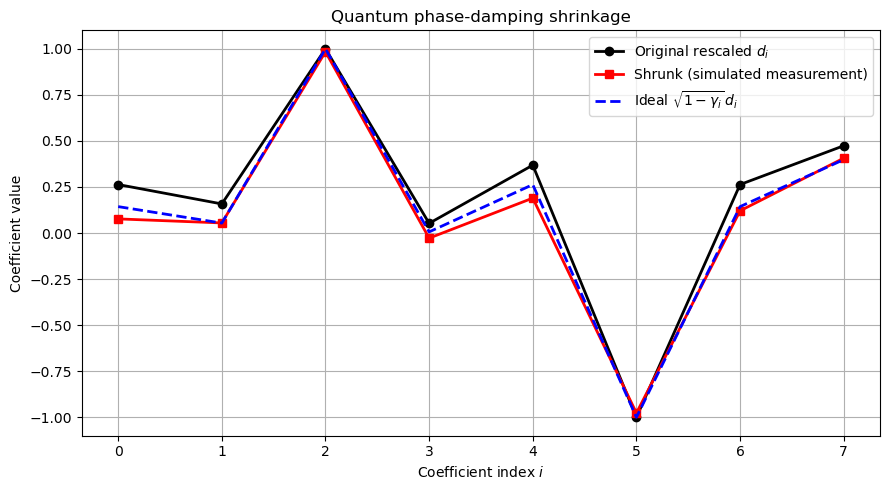

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

# -------------------------------------------------
# (1) Get / define data from the notebook
# -------------------------------------------------
# If QThreshold16 already computed these, just assign them.
# Otherwise, here's a fallback example based on your previous sequence.

try:
    coeff_index
    d_vals
except NameError:
    # Fallback demo data (replace with your real ones)
    d = np.array([2, 1, 9, 0, 3, -10, 2, 4], dtype=float)
    d_vals = 2 * (d - d.min()) / (d.max() - d.min()) - 1  # rescaled [-1,1]
    coeff_index = np.arange(len(d_vals))

# gamma rule: same one you used before in QThreshold15/QThreshold16
def gamma_of_d(val):
    # Example rule:
    # gamma_i = cos(pi * |x_i| / 2)^4
    return float(np.cos(0.5 * np.pi * abs(val))**4)

gamma_vals = np.array([gamma_of_d(v) for v in d_vals])

# Ideal theoretical shrink curve from Kraus phase damping:
# <X> -> sqrt(1 - gamma_i) * x_i
theoretical_vals = np.sqrt(1.0 - gamma_vals) * d_vals

# Simulated "measured" values:
# add a small random perturbation to mimic shot noise / hardware noise
rng = np.random.default_rng(seed=2025)
measured_vals = theoretical_vals + rng.normal(loc=0.0, scale=0.03, size=len(theoretical_vals))

# -------------------------------------------------
# (2) Create figure with high-contrast styling
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

# Original coefficients
ax.plot(
    coeff_index,
    d_vals,
    marker='o', linestyle='-',
    color='black', linewidth=2, markersize=6,
    label='Original rescaled $d_i$'
)

# "Measured" shrunk (noisy) values
ax.plot(
    coeff_index,
    measured_vals,
    marker='s', linestyle='-',
    color='red', linewidth=2, markersize=6,
    label='Shrunk (simulated measurement)'
)

# Ideal theoretical shrink
ax.plot(
    coeff_index,
    theoretical_vals,
    linestyle='--',
    color='blue', linewidth=2,
    label=r'Ideal $\sqrt{1-\gamma_i}\,d_i$'
)

ax.set_xlabel('Coefficient index $i$')
ax.set_ylabel('Coefficient value')
ax.set_title(r'Quantum phase-damping shrinkage')
ax.grid(True)
ax.legend()
fig.tight_layout()

# -------------------------------------------------
# (3) Save BEFORE show(), with opaque bg
# -------------------------------------------------
png_name = "ex03_phase_damping.png"
pdf_name = "ex03_phase_damping.pdf"

fig.savefig(
    png_name,
    dpi=300,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    bbox_inches="tight"
)

fig.savefig(
    pdf_name,
    dpi=300,
    facecolor="white",
    edgecolor="white",
    transparent=False,
    bbox_inches="tight"
)

# optional: confirm file sizes are nonzero so you don't upload a blank file
print("Saved PNG:", os.path.abspath(png_name),
      os.path.getsize(png_name), "bytes")
print("Saved PDF:", os.path.abspath(pdf_name),
      os.path.getsize(pdf_name), "bytes")

plt.show()
